# Práctica de Redes Neuronales - Notebook 2

## Bootcamp Python - PY4
## Módulo 3: Deep Learning y NLP

En el notebook anterior armamos el **Modelo A - El Minimalista**: una red
neuronal simple, con una sola capa oculta pequeña, entrenada sobre el dataset
de Customer Churn.

Hoy vamos a construir las otras dos variantes del sandbox de experimentación:

- **Modelo B - El Profundo**: múltiples capas ocultas, con más capacidad de
  aprendizaje (Deep Learning).
- **Modelo C - El Optimizado**: la misma idea de arquitectura profunda, pero
  usando técnicas para mejorar la generalización: `Dropout`, regularización, y
  `EarlyStopping`.

### Lo que vamos a hacer en este notebook:

1. Repasar rápido la preparación de datos (ya la hicimos la clase pasada).
2. Reconstruir el Modelo A como referencia rápida.
3. Construir y entrenar el Modelo B, y observar qué pasa cuando le damos a la
   red mucha más capacidad de la que el problema necesita.
4. Construir y entrenar el Modelo C, incorporando `Dropout`, regularización
   L2, y `EarlyStopping`.
5. Hacer una primera comparación numérica entre los tres modelos.


## 0. Repaso rápido: preparando el entorno y los datos

Antes de construir los nuevos modelos, repetimos rápidamente los pasos que ya
hicimos la clase pasada: importar librerías, cargar el dataset de Churn,
limpiarlo, codificar las variables categóricas, y dejar todo listo en
`X_train_scaled`, `X_test_scaled`, `y_train` y `y_test`.

No nos vamos a detener a explicar cada paso de nuevo (ya lo hicimos en el
Notebook 1). Si tenés dudas de por qué se hace algún paso en particular, podés
volver a ese notebook.


In [1]:
# Importamos las librerias para manejo de datos
import pandas as pd
import numpy as np

# Importamos matplotlib para graficar
import matplotlib.pyplot as plt

# Importamos herramientas de preprocesamiento de scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Importamos tensorflow y keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping

# Fijamos semillas para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)


In [2]:
# Cargamos el dataset de Customer Churn
url = "https://raw.githubusercontent.com/Camille-Le-Roy/data_analytics_resources/main/Datasets/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# Repetimos la limpieza que hicimos la clase pasada
data = df.copy()
data = data.drop(columns=["customerID"])
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")
data = data.dropna(subset=["TotalCharges"])

# Codificamos la variable objetivo y las variables categoricas
data["Churn"] = data["Churn"].map({"Yes": 1, "No": 0})
X = data.drop(columns=["Churn"])
y = data["Churn"]
X = pd.get_dummies(X, drop_first=True)

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling: ajustamos con train y aplicamos a train y test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

n_features = X_train_scaled.shape[1]
print("Cantidad de features de entrada:", n_features)
print("Tamano de X_train:", X_train_scaled.shape)
print("Tamano de X_test:", X_test_scaled.shape)


Cantidad de features de entrada: 30
Tamano de X_train: (5625, 30)
Tamano de X_test: (1407, 30)


### Función para graficar las curvas de entrenamiento

Vamos a reutilizar la misma función de la clase pasada para graficar las
curvas de loss y accuracy de entrenamiento vs validación. La vamos a usar para
cada modelo que construyamos hoy.


In [3]:
# Funcion para graficar loss y accuracy de entrenamiento vs validacion
def graficar_historia(history, titulo):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history["loss"], label="Train")
    axes[0].plot(history.history["val_loss"], label="Validation")
    axes[0].set_title(f"{titulo} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(history.history["accuracy"], label="Train")
    axes[1].plot(history.history["val_accuracy"], label="Validation")
    axes[1].set_title(f"{titulo} - Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


## 1. Reconstruyendo el Modelo A como referencia

Antes de construir los modelos nuevos, volvemos a entrenar el Modelo A tal
cual lo dejamos la clase pasada. Nos va a servir como punto de referencia
(baseline) para comparar contra el Modelo B y el Modelo C.

Recordá que el Modelo A es el más simple: una sola capa oculta con 8
neuronas.


In [4]:
# Reconstruimos el Modelo A: una sola capa oculta pequena
modelo_a = Sequential([
    # Primera capa: recibe las variables de entrada y aprende 8 representaciones nuevas usando ReLU
    Dense(8, activation="relu", input_shape=(n_features,)),

    # Capa de salida: una neurona con sigmoid para obtener una probabilidad de clase binaria
    Dense(1, activation="sigmoid")
])

# Configuramos cómo se entrenará la red:
# Adam actualiza los pesos, binary_crossentropy mide el error y accuracy muestra el rendimiento
modelo_a.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Entrenamos la red con los datos escalados.
# Guardamos el historial para poder analizar loss y accuracy durante las epochs.
history_a = modelo_a.fit(
    X_train_scaled,   # Variables de entrada del conjunto de entrenamiento
    y_train,          # Clases reales que el modelo intenta predecir
    epochs=50,        # Número de veces que la red verá todo el conjunto de entrenamiento
    batch_size=32,    # Número de ejemplos usados antes de actualizar los pesos
    validation_split=0.2,  # Reserva 20% del entrenamiento para validar el modelo
    verbose=0         # No muestra el progreso de cada epoch en pantalla
)

print("Modelo A entrenado. Ultimo accuracy de validacion:",
      round(history_a.history["val_accuracy"][-1], 4))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Modelo A entrenado. Ultimo accuracy de validacion: 0.8018


## 2. Modelo B: El Profundo

El Modelo A tenía una sola capa oculta con pocas neuronas. Ahora vamos a
construir una red mucho más grande: varias capas ocultas, cada una con más
neuronas. A esto se refiere el nombre "Deep Learning": redes con múltiples
capas ocultas apiladas, donde cada capa aprende representaciones cada vez más
complejas a partir de la salida de la capa anterior.

Vamos a usar la siguiente arquitectura:

- Capa oculta 1: 64 neuronas, activación `relu`.
- Capa oculta 2: 32 neuronas, activación `relu`.
- Capa oculta 3: 16 neuronas, activación `relu`.
- Capa de salida: 1 neurona, activación `sigmoid`   

```text
Entrada
(n_features)
     |
     v
[ Dense 64 neuronas ]
[ Activation ReLU ]
     |
     v
[ Dense 32 neuronas ]
[ Activation ReLU ]
     |
     v
[ Dense 16 neuronas ]
[ Activation ReLU ]
     |
     v
[ Dense 1 neurona ]
[ Activation Sigmoid ]
     |
     v
Probabilidad clase positiva
```

Esto le da a la red muchísima más capacidad (muchos más parámetros para
ajustar) que el Modelo A. La pregunta que nos interesa es: ¿más capacidad
significa automáticamente un mejor modelo? Vamos a entrenarlo y ver qué pasa
con sus curvas de loss y accuracy.


In [5]:
# Construimos el Modelo B: arquitectura profunda, varias capas ocultas
modelo_b = Sequential([
    Dense(64, activation="relu", input_shape=(n_features,)),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

# Mostramos el resumen de la arquitectura
modelo_b.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

Fijate en el `summary()` cuántos parámetros entrenables tiene el
Modelo B en comparación con el Modelo A. Esa diferencia de tamaño es
justamente lo que puede llevar a un modelo a memorizar el set de
entrenamiento en lugar de aprender patrones generales.

Compilamos y entrenamos el Modelo B con la misma configuración que usamos
para el Modelo A, para que la comparación sea justa.


In [6]:
# Compilamos el Modelo B con la misma configuración que el Modelo A
modelo_b.compile(
    optimizer="adam",              # Optimizador que actualiza los pesos de la red
    loss="binary_crossentropy",    # Función que mide el error en clasificación binaria
    metrics=["accuracy"]           # Métrica usada para evaluar el rendimiento
)

# Entrenamos el Modelo B
history_b = modelo_b.fit(
    X_train_scaled,                # Datos de entrada para entrenar
    y_train,                       # Etiquetas reales del conjunto de entrenamiento
    epochs=50,                     # Número de veces que la red ve los datos completos
    batch_size=32,                 # Número de ejemplos por actualización de pesos
    validation_split=0.2,          # Reserva 20% para validar durante el entrenamiento
    verbose=1                      # Muestra el progreso de cada época
)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7709 - loss: 0.4653 - val_accuracy: 0.7929 - val_loss: 0.4183
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8024 - loss: 0.4203 - val_accuracy: 0.7884 - val_loss: 0.4157
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8080 - loss: 0.4101 - val_accuracy: 0.7893 - val_loss: 0.4161
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8144 - loss: 0.4027 - val_accuracy: 0.7902 - val_loss: 0.4175
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8202 - loss: 0.3968 - val_accuracy: 0.7947 - val_loss: 0.4201
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8236 - loss: 0.3917 - val_accuracy: 0.8000 - val_loss: 0.4237
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8271 - loss: 0.3868 - val_accuracy: 0.7956 - val_loss: 0.4280
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8264 - loss: 0.3820 - val_accuracy: 0.

In [7]:
# model.fit()
#     |
#     |
#     ├── 1. Forward pass
#     |       prediction = model(X)
#     |
#     ├── 2. Calculate loss
#     |       loss = binary_crossentropy(y_true, y_pred)
#     |
#     ├── 3. Backpropagation
#     |       calculate gradients of each weight
#     |
#     └── 4. Adam optimizer
#             update weights using gradients

**Recordatorio de cómo aprende una red neuronal**  

1. **Forward pass**  
   La red recibe los datos de entrada y calcula una predicción usando sus pesos actuales.

2. **Cálculo del loss**  
   Se compara la predicción del modelo con el valor real para medir qué tan equivocada está la red.

3. **Backpropagation**  
   La red calcula los **gradientes**, es decir, cuánto contribuyó cada peso al error y en qué dirección debería modificarse para reducirlo.

4. **Gradient Descent**  
   Es la idea general de actualizar los pesos siguiendo la dirección que reduce el *loss*.

5. **Adam (optimizador)**  
   Adam es un algoritmo basado en gradient descent que utiliza los gradientes calculados por backpropagation para actualizar los pesos. Además, adapta el tamaño de los pasos para cada peso, lo que suele hacer el entrenamiento más rápido y estable.

En resumen:

**Forward pass → calcula la predicción**  
**Loss → mide el error**  
**Backpropagation → calcula qué pesos deben cambiar y en qué dirección**  
**Adam → decide cuánto cambiar esos pesos y los actualiza**

**Nota: relación entre batches y epochs**
```python
    epochs=50,                   
    batch_size=32,  
```
Aqui hemos dividido los datos de entrenamiento en **batches de 32 ejemplos**.

Para cada **batch**, la red realiza el ciclo completo de aprendizaje (como explicado arriba).

Cuando todos los batches han sido procesados, se completa **una epoch**.

La red verá todo el dataset 50 veces. Los pesos se actualizan después de cada batch. Por lo tanto, cada epoch contiene múltiples actualizaciones de pesos.

In [8]:
# Epoch 1
# │
# ├── Batch 1
# │     Forward pass
# │     Loss calculation
# │     Backpropagation
# │     Adam updates weights ✅
# │
# ├── Batch 2
# │     Forward pass
# │     Loss calculation
# │     Backpropagation
# │     Adam updates weights ✅
# │
# ├── Batch 3
# │     Forward pass
# │     Loss calculation
# │     Backpropagation
# │     Adam updates weights ✅
# │
# ...
# │
# └── Last batch
#       Forward pass
#       Loss calculation
#       Backpropagation
#       Adam updates weights ✅
#
# → Epoch 1 completed

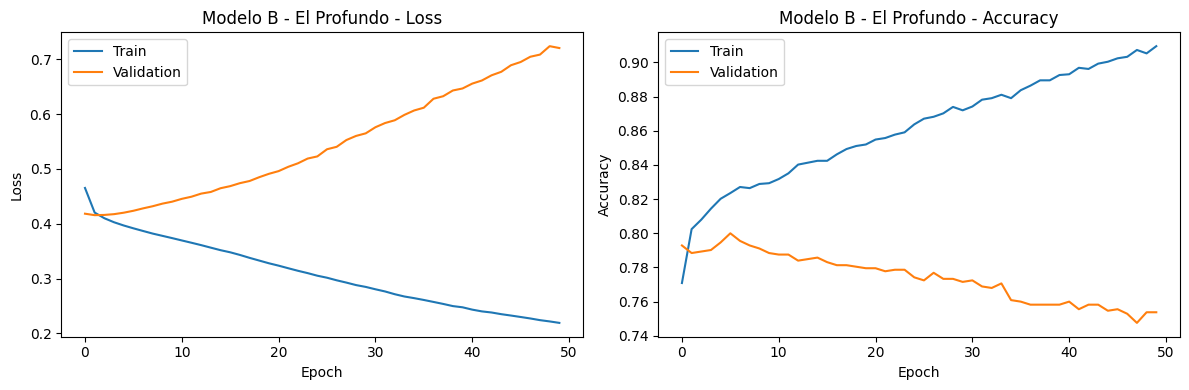

In [9]:
# Graficamos las curvas del Modelo B
graficar_historia(history_b, "Modelo B - El Profundo")


### Para observar en el gráfico del Modelo B

Prestá atención a la curva de loss:

- ¿El loss de entrenamiento sigue bajando durante todo el entrenamiento?
- ¿Qué pasa con el loss de validación? ¿En algún momento deja de bajar, o
  incluso empieza a subir, mientras el de entrenamiento sigue bajando?

Si ves esa separación creciente entre ambas curvas, eso es overfitting: el
modelo tiene tanta capacidad que empieza a memorizar detalles específicos del
set de entrenamiento que no generalizan al set de validación.

Vamos a confirmarlo evaluando el Modelo B sobre el conjunto de test.




------------------------

**Interpretación de las curvas**

Durante las primeras épocas, el modelo aprende correctamente:
- La **accuracy de entrenamiento aumenta** rápidamente.
- La **loss de entrenamiento disminuye**, indicando que el modelo está reduciendo sus errores.
- La **accuracy de validación también mejora ligeramente al inicio**, lo que indica que está aprendiendo patrones útiles.

Sin embargo, después de aproximadamente la época 5-10 aparece una separación entre ambas curvas:

- La **accuracy de entrenamiento continúa aumentando** hasta aproximadamente 91%.
- La **accuracy de validación deja de mejorar y empieza a disminuir**, llegando alrededor de 74%.
- La **loss de entrenamiento sigue bajando**, mientras que la **validation loss aumenta continuamente**.

Este comportamiento es una señal clara de **overfitting (sobreajuste)**.

El modelo está aprendiendo demasiado bien los ejemplos del conjunto de entrenamiento, incluyendo detalles específicos o ruido, pero pierde capacidad para generalizar a datos nuevos.

------------------------

In [10]:
# Evaluamos el Modelo B sobre el conjunto de test
test_loss_b, test_accuracy_b = modelo_b.evaluate(X_test_scaled, y_test, verbose=0)

print("Modelo B - Loss en test:", round(test_loss_b,3))
print("Modelo B - Accuracy en test:", round(test_accuracy_b,3))


Modelo B - Loss en test: 0.722
Modelo B - Accuracy en test: 0.748


La evaluación sobre el conjunto de **test** nos dice:

> "Después de este proceso de entrenamiento, el modelo final consigue aproximadamente X% de accuracy sobre datos completamente nuevos que nunca ha visto."

**Curvas → diagnostican el proceso de aprendizaje.**  
**Test → mide el rendimiento final y la capacidad de generalización.**

## 3. Modelo C: El Optimizado

El Modelo B nos mostró que darle mucha capacidad a la red sin cuidado puede
llevar a overfitting. El Modelo C va a usar la misma arquitectura profunda,
pero incorporando técnicas pensadas específicamente para mejorar la
generalización:

- **Dropout**: durante el entrenamiento, en cada paso, "apaga" al azar un
  porcentaje de las neuronas de una capa. Esto obliga a la red a no depender
  demasiado de neuronas específicas, y ayuda a que aprenda patrones más
  generales en vez de memorizar.  

- **Regularización L2**: agrega una penalización a la función de loss cuando
  los pesos de la red se vuelven muy grandes. Esto empuja a la red a usar
  pesos más chicos y simples, lo cual también ayuda a evitar el overfitting.  
  
- **EarlyStopping**: un callback que monitorea el loss de validación durante
  el entrenamiento, y detiene el entrenamiento automáticamente si deja de
  mejorar durante una cantidad de epochs seguidas (esto se llama
  `patience`). Así evitamos seguir entrenando (y potencialmente
  sobreajustando) más allá del punto óptimo.

Vamos a usar la misma cantidad de capas y neuronas que en el Modelo B, para
que la comparación sea justa: la única diferencia entre B y C van a ser estas
técnicas de optimización.


In [11]:
# Construimos el Modelo C: misma arquitectura que B, pero agregando
# regularización L2 y Dropout para reducir el overfitting.
modelo_c = Sequential([

    Dense(
        64,
        activation="relu",                       # Función de activación de la capa
        input_shape=(n_features,),               # Número de variables de entrada (espera un tuple (,))
        kernel_regularizer=regularizers.l2(0.001)  # Penaliza pesos grandes (L2) (aqui 0.001 es la fuerza de regularization)
    ),
    Dropout(0.3),                               # Apaga aleatoriamente el 30% de las neuronas durante el entrenamiento

    Dense(
        32,
        activation="relu",                       # Segunda capa oculta
        kernel_regularizer=regularizers.l2(0.001)  # Regularización L2
    ),
    Dropout(0.3),                               # Apaga aleatoriamente el 30% de las neuronas durante el entrenamiento

    Dense(
        16,
        activation="relu",                       # Tercera capa oculta
        kernel_regularizer=regularizers.l2(0.001)  # Regularización L2
    ),
    Dropout(0.3),                               # Apaga aleatoriamente el 30% de las neuronas durante el entrenamiento

    Dense(
        1,
        activation="sigmoid"                     # Capa de salida para clasificación binaria
    )
])

# Mostramos la arquitectura del modelo
modelo_c.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

### Configurando EarlyStopping

Además de compilar el modelo, esta vez vamos a definir un callback de
`EarlyStopping`. Le decimos que:

- Monitoree `val_loss` (el loss sobre el set de validación).
- Tenga `patience=10`: si el `val_loss` no mejora durante 10 epochs seguidas,
  detiene el entrenamiento.
- Use `restore_best_weights=True`: al terminar, se queda con los pesos del
  epoch donde el `val_loss` fue más bajo, no con los del último epoch.

Como el entrenamiento se puede cortar antes de tiempo, le vamos a dar más
epochs de margen (100 en vez de 50): confiamos en que `EarlyStopping` va a
frenar el entrenamiento antes de que eso sea un problema.


**¿Qué es un *callback*?**
>
>Un **callback** es un **objeto** que Keras ejecuta automáticamente durante el entrenamiento para **supervisar o modificar** lo que está ocurriendo.
>
>Podemos imaginarlo como un **asistente** que observa el proceso de entrenamiento y toma decisiones cuando es necesario.

In [12]:
# Compilamos el Modelo C
modelo_c.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Definimos el callback de EarlyStopping
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# Entrenamos el Modelo C, con mas epochs de margen y el callback de EarlyStopping
history_c = modelo_c.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6958 - loss: 0.6654 - val_accuracy: 0.7636 - val_loss: 0.5389
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7644 - loss: 0.5801 - val_accuracy: 0.7964 - val_loss: 0.5089
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7842 - loss: 0.5540 - val_accuracy: 0.7973 - val_loss: 0.4976
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7829 - loss: 0.5304 - val_accuracy: 0.8036 - val_loss: 0.4858
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7896 - loss: 0.5253 - val_accuracy: 0.8000 - val_loss: 0.4811
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7940 - loss: 0.5157 - val_accuracy: 0.8027 - val_loss: 0.4752
Epoch 7/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7920 - loss: 0.5051 - val_accuracy: 0.8009 - val_loss: 0.4696
Epoch 8/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7982 - loss: 0.4943 - val_accu

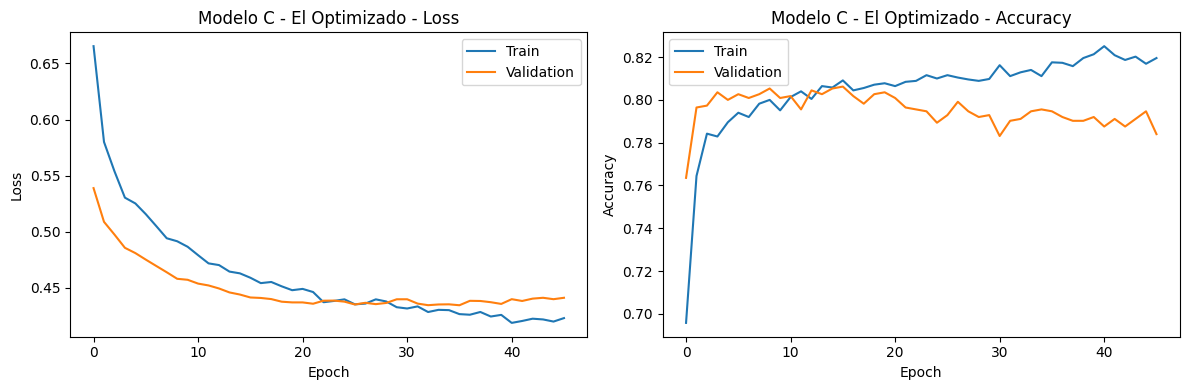

Cantidad de epochs efectivamente entrenados: 46


In [13]:
# Graficamos las curvas del Modelo C
graficar_historia(history_c, "Modelo C - El Optimizado")

# Revisamos en que epoch se detuvo realmente el entrenamiento
print("Cantidad de epochs efectivamente entrenados:", len(history_c.history["loss"]))


### Para observar en el gráfico del Modelo C

Compará esta curva con la del Modelo B:

- ¿La brecha entre el loss de entrenamiento y el de validación es más chica
  que en el Modelo B?
- ¿En cuántos epochs se detuvo el entrenamiento? ¿Llegó a los 100, o
  `EarlyStopping` lo cortó antes?

Esto es exactamente lo que buscábamos: usar la capacidad de un modelo
profundo, pero con herramientas que lo ayuden a generalizar mejor en lugar de
memorizar.  
  
  


----------


**Interpretación de las curvas del Modelo C**

El comportamiento del modelo es mucho más estable que el del Modelo B.

Durante las primeras épocas:
- La **loss de entrenamiento disminuye rápidamente**, indicando que el modelo está aprendiendo patrones útiles.
- La **loss de validación también disminuye**, lo que muestra que las mejoras del modelo se trasladan correctamente a datos que no ha visto durante el entrenamiento.
- Tanto la **accuracy de entrenamiento** como la **accuracy de validación** aumentan de forma rápida durante las primeras épocas.

A partir de aproximadamente la época 20-25, las curvas comienzan a estabilizarse:

- La **loss de entrenamiento continúa disminuyendo lentamente**.
- La **loss de validación deja de mejorar y permanece prácticamente constante**, con un ligero aumento al final del entrenamiento.
- La **accuracy de entrenamiento sigue aumentando**, mientras que la **accuracy de validación se mantiene cercana al 79-80%**, con pequeñas fluctuaciones normales.

Existe una ligera separación entre las curvas de entrenamiento y validación, lo que indica que todavía hay un pequeño grado de **overfitting**. Sin embargo, esta diferencia es mucho menor que en el Modelo B.

En conclusión:
- La combinación de **Dropout** y **regularización L2** ha conseguido reducir significativamente el sobreajuste observado en el Modelo B.
- El modelo sigue aprendiendo correctamente sobre el conjunto de entrenamiento, pero mantiene un rendimiento mucho más estable sobre el conjunto de validación.
- Aunque las últimas épocas muestran una ligera pérdida de capacidad de generalización, el Modelo C consigue un mejor equilibrio entre aprendizaje y generalización, convirtiéndose en un modelo más robusto para datos no vistos.

In [15]:
# Evaluamos el Modelo C sobre el conjunto de test
test_loss_c, test_accuracy_c = modelo_c.evaluate(X_test_scaled, y_test, verbose=0)

print("Modelo C - Loss en test:", test_loss_c)
print("Modelo C - Accuracy en test:", test_accuracy_c)


Modelo C - Loss en test: 0.458735853433609
Modelo C - Accuracy en test: 0.7896233201026917


## 4. Primera comparación entre los tres modelos

Antes de la mesa de auditoría completa (que vamos a hacer en el próximo
notebook, comparando las curvas de los tres modelos lado a lado), hagamos una
primera comparación rápida de los resultados finales sobre el conjunto de
test. Para eso, evaluamos también el Modelo A sobre test (todavía no lo
habíamos hecho en este notebook) y armamos una tabla con los tres modelos.


In [16]:
# Evaluamos el Modelo A sobre el conjunto de test, en este notebook
test_loss_a, test_accuracy_a = modelo_a.evaluate(X_test_scaled, y_test, verbose=0)

# Armamos la tabla comparativa con los tres modelos
resultados = pd.DataFrame({
    "Modelo": ["A - Minimalista", "B - Profundo", "C - Optimizado"],
    "Test Loss": [test_loss_a, test_loss_b, test_loss_c],
    "Test Accuracy": [test_accuracy_a, test_accuracy_b, test_accuracy_c],
    "Cantidad de parametros": [
        modelo_a.count_params(),
        modelo_b.count_params(),
        modelo_c.count_params(),
    ],
})

resultados


,Modelo,Test Loss,Test Accuracy,Cantidad de parametros
0,A - Minimalista,0.432207,0.793888,257
1,B - Profundo,0.721749,0.748401,4609
2,C - Optimizado,0.458736,0.789623,4609


Guardamos los tres `history` (`history_a`, `history_b`, `history_c`) y
los tres modelos, porque los vamos a volver a usar en el próximo notebook para
la comparación completa.

### Preguntas para discutir

- ¿El Modelo B, con más parámetros, logró un mejor resultado en test que el
  Modelo A? ¿Por qué podría no ser así, a pesar de tener mucha más capacidad?
- ¿El Modelo C logró un resultado más parecido entre entrenamiento y
  validación que el Modelo B? ¿Eso es señal de mejor generalización?
- ¿Qué pasaría si aumentamos el `patience` de `EarlyStopping`? ¿Y si lo
  bajamos mucho, a 1 o 2?


**1. ¿El Modelo B, con más parámetros, logró un mejor resultado en test que el Modelo A? ¿Por qué podría no ser así, a pesar de tener mucha más capacidad?**

No necesariamente. Aunque el Modelo B tiene una capacidad mucho mayor para aprender patrones complejos, las curvas muestran un claro **overfitting**:

- La **loss de entrenamiento** sigue disminuyendo constantemente.
- La **loss de validación** aumenta de forma continua.
- La **accuracy de entrenamiento** sigue mejorando, mientras que la **accuracy de validación** disminuye.

Esto indica que el modelo está **memorizando los datos de entrenamiento** en lugar de aprender patrones que generalicen a datos nuevos. Por ello, tener más parámetros no garantiza un mejor rendimiento sobre el conjunto de test.

---

**2. ¿El Modelo C logró un resultado más parecido entre entrenamiento y validación que el Modelo B? ¿Eso es señal de mejor generalización?**

Sí. En el Modelo C, las curvas de entrenamiento y validación permanecen mucho más cercanas durante todo el entrenamiento.

- La **loss de validación** deja de mejorar, pero no aumenta de forma tan pronunciada como en el Modelo B.
- La **accuracy de validación** se mantiene relativamente estable alrededor del 79-80%, mientras que la accuracy de entrenamiento aumenta lentamente.

Esto indica que **Dropout**, la **regularización L2** y **EarlyStopping** ayudan a reducir el overfitting, permitiendo que el modelo generalice mejor sobre datos que no ha visto anteriormente.

---

**3. ¿Qué pasaría si aumentamos el `patience` de `EarlyStopping`? ¿Y si lo bajamos mucho, a 1 o 2?**

Si aumentamos el valor de **`patience`**, el entrenamiento continuará durante más épocas aunque la métrica de validación deje de mejorar. Esto puede permitir que el modelo encuentre una solución mejor si la mejora aparece unas pocas épocas más tarde, aunque también aumenta el riesgo de sobreajuste.

Por el contrario, si reducimos mucho el **`patience`** (por ejemplo a 1 o 2), el entrenamiento podría detenerse demasiado pronto debido a pequeñas fluctuaciones normales de la validación. En ese caso, el modelo podría dejar de entrenarse antes de alcanzar su mejor rendimiento, produciendo un modelo con **underfitting** o insuficientemente entrenado.

## Cierre de la sesión

Hoy hicimos lo siguiente:

- Construimos el **Modelo B - El Profundo**, con varias capas ocultas, y
  observamos cómo más capacidad no necesariamente significa mejores
  resultados, y puede llevar a overfitting.
- Construimos el **Modelo C - El Optimizado**, incorporando `Dropout`,
  regularización L2 y `EarlyStopping`, y comparamos su comportamiento con el
  del Modelo B.
- Hicimos una primera comparación numérica de los tres modelos.

### Para el próximo notebook

En la siguiente sesión vamos a hacer la **mesa de auditoría** completa:

- Comparar las curvas de loss y accuracy de los tres modelos, lado a lado.
- Identificar visualmente el punto exacto de overfitting en cada modelo.
- Discutir en profundidad el impacto de las funciones de activación y del uso
  de `EarlyStopping` para la generalización.
